# Backends: Particle-Spray Streams

This notebook describes how to generate particle-spray tidal streams
(`fardal15spraydf` and `chen24spraydf`) with [JAX](https://docs.jax.dev/)
and how to differentiate them with respect to the potential. See the [quick
start](quickstart.ipynb) for an introduction to galpy's backends and the
[particle-spray tutorial](../streams/streamspraydf.ipynb) for the models
themselves.

Particle-spray models release particles from the progenitor at random times
with random offsets in position and velocity and integrate them forward. On
the backends, `sample` and the track-fitting method `streamTrack` are pure
functions of the progenitor's orbit, the potential, the progenitor's mass,
and a random key: the stripping times are drawn by inverse transformation of
uniform variates, the offsets are reparameterized normal variates, the
progenitor and the particles are integrated in the backend, and the track is
fit with a penalized spline. The whole computation can be compiled with
`jax.jit` and differentiated with respect to every parameter.

In [1]:
%matplotlib inline
import time
import warnings

import jax

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy

from galpy.backend import random as grandom
from galpy.df import fardal15spraydf
from galpy.orbit import Orbit
from galpy.potential import LogarithmicHaloPotential
from galpy.util.conversion import mass_in_msol, time_in_Gyr

# A GD-1-like stream: progenitor phase-space position, mass, disruption time
ic = [1.56148083, 0.35081535, -1.15481504, 0.88719443, -0.47713334, 0.12019596]
mass = 2.0e4 / mass_in_msol(220.0, 8.0)
tdisrupt = 4.5 / time_in_Gyr(220.0, 8.0)
key = grandom.key(1, backend="jax")

## A stream and its derivative with respect to the potential

We sample the leading arm of a stream in a logarithmic halo with
flattening $q$, as a function of $q$. With a JAX key and a progenitor that is
set up from a JAX array, the sample is a JAX computation. We compute the
sample and its forward-mode derivative with respect to $q$ with `jax.jvp`,
compiled with `jax.jit`. Forward mode currently requires diffrax's direct
adjoint, `integrate_kwargs={"adjoint": "direct"}` (see the [orbits
notebook](orbits.ipynb)):

In [2]:
def leading_arm(q):
    pot = LogarithmicHaloPotential(normalize=1.0, q=q)
    spdf = fardal15spraydf(
        mass,
        progenitor=Orbit(jnp.asarray(ic)),
        pot=pot,
        tdisrupt=tdisrupt,
        integrate_kwargs={"adjoint": "direct"},
    )
    # (R,vR,vT,z,vz,phi) of each particle, shape (6,n)
    return spdf.sample(n=500, return_orbit=False, tail="leading", key=key)


arm_and_derivative = jax.jit(lambda q: jax.jvp(leading_arm, (q,), (1.0,)))
q0 = 0.9
start = time.perf_counter()
xv, dxv_dq = arm_and_derivative(q0)
print(f"First call (compiles): {time.perf_counter() - start:.1f} s")
start = time.perf_counter()
arm_and_derivative(q0)
print(f"Second call: {time.perf_counter() - start:.2f} s")

First call (compiles): 61.9 s


Second call: 1.91 s


`dxv_dq` is the change of every particle's phase-space position for a unit
change in $q$, with the random numbers held fixed. It agrees with a finite
difference of samples with the same key:

In [3]:
h = 1e-4
fd = (arm_and_derivative(q0 + h)[0] - arm_and_derivative(q0 - h)[0]) / (2.0 * h)
print(
    "Relative difference:",
    numpy.max(numpy.fabs(dxv_dq - fd)) / numpy.max(numpy.fabs(dxv_dq)),
)

Relative difference: 5.868208559499582e-06


A single derivative predicts the stream in a halo with a different
flattening. We compare the prediction for $q=q_0+0.01$ with a direct
sample at that $q$ (with the same random numbers): the left panel shows the
two streams, the right panel the change in $z$ of each particle, directly
and from the derivative:

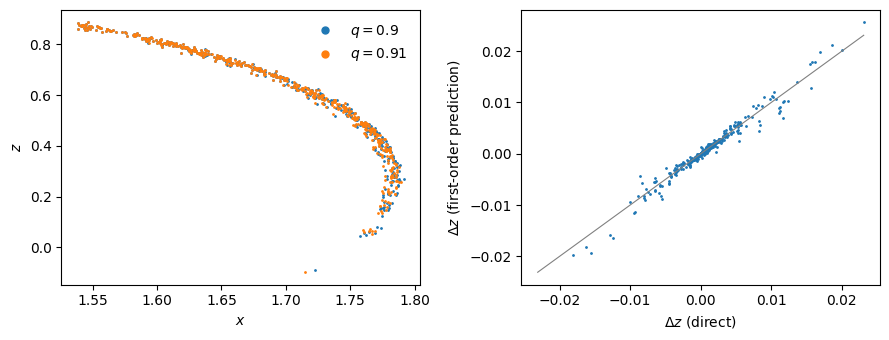

In [4]:
dq = 0.01
xv_dq = arm_and_derivative(q0 + dq)[0]
xv_pred = xv + dq * dxv_dq


def xz(xv):
    return xv[0] * jnp.cos(xv[5]), xv[3]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
ax1.plot(*xz(xv), ".", ms=2, label=rf"$q={q0}$")
ax1.plot(*xz(xv_dq), ".", ms=2, label=rf"$q={q0 + dq}$")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$z$")
ax1.legend(frameon=False, markerscale=5)
dz_direct = xz(xv_dq)[1] - xz(xv)[1]
dz_pred = xz(xv_pred)[1] - xz(xv)[1]
ax2.plot(dz_direct, dz_pred, ".", ms=2)
lim = float(jnp.max(jnp.fabs(dz_direct)))
ax2.plot([-lim, lim], [-lim, lim], color="0.5", lw=0.8)
ax2.set_xlabel(r"$\Delta z$ (direct)")
ax2.set_ylabel(r"$\Delta z$ (first-order prediction)")
fig.tight_layout()

Reverse mode (`jax.grad`, `jax.vjp`) works with the default adjoint and is
the efficient choice for the derivative of a scalar, such as a likelihood,
with respect to many parameters.

## Smooth statistics versus fitted tracks

For fitting a stream model to data, the derivative of a smooth statistic of
the particles is well-behaved. For example, the derivative of the mean of
$z^2$ over the particles follows from the forward-mode derivative above,
$\mathrm{d}\langle z^2\rangle/\mathrm{d}q = \langle 2 z\, \mathrm{d}z/\mathrm{d}q\rangle$,
and agrees with a finite difference:

In [5]:
print(
    jnp.mean(2.0 * xv[3] * dxv_dq[3]),
    (
        jnp.mean(arm_and_derivative(q0 + h)[0][3] ** 2)
        - jnp.mean(arm_and_derivative(q0 - h)[0][3] ** 2)
    )
    / (2.0 * h),
)

0.04529158763404374 0.04529156078347807


`streamTrack` fits a smooth track through the particles and returns a
`StreamTrack` object; we differentiate the track through its accessors,
here the $x$ coordinate at a few points along the leading arm, again in
forward mode and compiled:

In [6]:
tps = jnp.linspace(0.0, 0.2, 5)  # progenitor times along the leading arm


def track_x(q):
    pot = LogarithmicHaloPotential(normalize=1.0, q=q)
    spdf = fardal15spraydf(
        mass,
        progenitor=Orbit(jnp.asarray(ic)),
        pot=pot,
        tdisrupt=tdisrupt,
        integrate_kwargs={"adjoint": "direct"},
    )
    track = spdf.streamTrack(n=500, tail="leading", key=key)
    return track.x(tps)


track_and_derivative = jax.jit(lambda q: jax.jvp(track_x, (q,), (1.0,)))
start = time.perf_counter()
x_track, dx_track_dq = track_and_derivative(q0)
print(f"First call (compiles): {time.perf_counter() - start:.1f} s")
print(x_track)
print(dx_track_dq)

First call (compiles): 78.0 s
[1.5386006  1.56223017 1.58470737 1.60601824 1.6261509 ]
[-0.0421622  -0.04906043 -0.05664769 -0.06489006 -0.07375062]


This derivative holds the discrete choices of the track fit (the binning of
the particles and the knots and smoothing of the spline) fixed. These choices
change with $q$, so the fitted track is not a smooth function of $q$, and a
finite difference of the fitted track does not converge onto the derivative:

In [7]:
for h in [1e-3, 1e-4]:
    print(
        h,
        (track_and_derivative(q0 + h)[0] - track_and_derivative(q0 - h)[0]) / (2.0 * h),
    )

0.001 [ 0.0097974   0.00830263  0.00611883  0.00327993 -0.00017718]


0.0001 [-0.02093024 -0.02071514 -0.02118908 -0.0223181  -0.02406536]


For a likelihood, smooth statistics of the particles themselves are
therefore the better target.

## Notes

* The progenitor should be set up from a JAX array, as above: a progenitor
  set up from a list or NumPy array is integrated differently and the
  derivative then agrees with finite differences of plain calls only to about
  $10^{-4}$.
* `chen24spraydf` works in the same way.
* The same computation runs with PyTorch, with a progenitor set up from a
  tensor, a PyTorch key, and potential parameters given as tensors; the
  particles are integrated with torchode. In eager mode on a CPU this is
  slow (about a minute for 500 particles); it can be compiled with
  `torch.compile` or run on a GPU.
* Each particle's orbit is one more orbit in a batch, so on a GPU large
  streams cost little more than small ones.